____
____
<h1 align="center">
<font color=#18453b>
MHNC Solver for effective potential
</font>
</h1> 


<h4 align="center">
December 2021
</h4>

____
____
The input you will need to have at hand are:  
- the dilute pair correlation function $g_{dil}(r)$
- bridge function $b(r)$
- Packing fraction $\eta$. 
- Grid parameters.  

The basic physical model is a many-body system of particles interacting through a pair interaction of the form:         
$$ u(r) = + \infty \; \; \; \; \; se \; \; r < 1$$  
$$ u(r) = - log( c_{2Body}(r) + 1 ) \; \; \; \; \; se \; \; r > 1 .$$


Let's write MHNC equations in terms of our dimensionless units:
$$\gamma(k) = \frac{\rho^* c^2(k)}{1 - \rho^* c(k)},$$   
$$g(r) = e^{-u(r) - b(r) + \gamma(r)},$$   
where $\rho^* = \frac{6}{\pi} \; \eta$  and $b(r)$ is the bridge function.   

When the system has come to convergence there is a routine that check the consistency between virial and compressibility route.

## Dimensionless compressibility
$$ \frac{\rho \chi_T}{\beta} = S(0)$$   

## Dimensionless pressure
$$ Z \equiv \frac{\beta P}{\rho} = 1 + \frac{2 \pi \rho^*}{3} g(1) - \frac{2 \pi \rho^*}{3} \int_{1}^{+\inf} \; \frac{d u(r)}{d r} \; g(r) \; r^3 \; dr $$  


## Virial-Compressibility Consistency
$$ \frac{1}{S(0)} = \rho^* \frac{\partial Z}{\partial \rho^*} + Z$$

In [385]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("bmh")
plt.rcParams.update({'font.size': 24})

from scipy import fftpack
# %matplotlib inline
# %matplotlib notebook
import seaborn as sns
from scipy import integrate

## Grid

In [386]:
# run parameters
num_iterations = 500
alpha = 0
# r binning
N_bins = 2500
R_max = 25
del_r = R_max/N_bins
# error is minimized when using bin centers
r_array = np.linspace(del_r/2+5e-5,R_max-del_r/2+5e-5,N_bins)
energy_iter = np.zeros(num_iterations)      #Excess Energy per Particle
pressure_iter = np.zeros(num_iterations)    #Dimensionless Pressure
#In order to compute pressure for hard-core pair potential
idx = (np.abs(r_array - 1)).argmin()
if(r_array[idx]< 1):
    idx = idx+1

# k binning
del_k = np.pi/(N_bins*del_r)
K_max = del_k*N_bins
k_array = np.linspace(del_k/2,K_max-del_k/2,N_bins)

# precompute factors 
fact_r_2_k = 2*np.pi*del_r                 
fact_k_2_r = del_k/(4.*np.pi**2)    

## Fourier Transform

In [387]:
# f(k) = FT[f(r)]
def FT_r_2_k(input_array):
    from_dst = fact_r_2_k*fftpack.dst(r_array*input_array,type=4)     #Modified
    return from_dst/k_array

# f(r) = IFT[f(k)]
def FT_k_2_r(input_array):
    from_idst = fact_k_2_r*fftpack.idst(k_array*input_array,type=4)   #Modified
    return from_idst/r_array

## Parameters

In [388]:
Filename = 'fourier'
bridge = np.loadtxt('Bridge_function/bridge_eta0p443.out',usecols=(1))
#bridge = np.zeros(N_bins)
g_dil = 'g_EqGrid_deltar_0p01_Yukawa_Nohydro_Pe10_kappa2_Gamma150.in'
#bridge = np.zeros(N_bins)
beta = 0.6
eta = 0.4
rho = np.array([6 / np.pi * eta + 1e-4,6 / np.pi * eta ])    #max 1.909859317102744

## Routines

In [389]:
#Potential initialization
pmf = -np.log( np.loadtxt(g_dil,usecols=(1)) )
u_tmp = np.zeros(N_bins)
j = 0
for i in range(N_bins):  
    if(r_array[i] < 1 or r_array[i] > 10 ):
        u_tmp[i] = 0
    else:
        u_tmp[i] = pmf[j]
        j = j + 1
        
# Returns a tuple of arrays with [u(r),u_s(r)]; it is the short-ranged u_s(r) that is used in the HNC solver.
# Note that u(r) itself is not needed for HNC, but is used for computing the energy, which is used to test convergence.
# This function assumes global variables Gamma, kappa and alpha.
def u(r_in):
    return [u_tmp, u_tmp * (1- np.exp(-alpha*r_in))]

# The initial condition is given through c(k), defined here. This should be consistent with the other definitions
# in this cell.
def initial_c_k(k_in):
    if(Filename == 'fourier'):   
        return FT_r_2_k(-u_tmp)
    else:
        return np.loadtxt(c_File,usecols=(1))
    
# Long range part of the potential in Fourier space. This could be computed with the Fourier routines, but
# I chose to precopmute things analytically when possible.
def u_long_l(k_in):
    return FT_r_2_k(u_tmp*np.exp(-alpha*r_array))

def Consistency_check(press,S0):
    Chi_S = 1 / S0   #Inverse of compressibility computed through Static Structure Factor
    Chi_P = rho[1] * (press[0] - press[1]) / (rho[0] - rho[1]) + press[1]  #Inverse of compressibility computed through pressure
    print("**Consistency Check:    ",Chi_S - Chi_P)

## Main

In [390]:
%%time
pressure = np.zeros(2)   #P(0) is valued at rho+del_rho, P(1) is valued at rho
counter = 0  #0-> is the first density, 1 is the second 1
for dimless_dens in rho:
    # set up initial arrays
    u_r, u_s_r = u(r_array)
    d_u_d_r = np.gradient(u_r,del_r)
    c_k = initial_c_k(k_array)
    u_l_k = u_long_l(k_array)
    c_s_k = c_k + u_l_k
    g_r = np.zeros(N_bins)

    # start the iteration loop
    for iteration in np.arange(num_iterations):
        gamma_s_k = (dimless_dens*c_s_k*c_k - u_l_k)/(1-dimless_dens*c_k)
        gamma_s_r = FT_k_2_r(gamma_s_k)  
        #HNC
        for i in range(N_bins):
            if(r_array[i]<1):
                g_r[i] = 0
            else:
                g_r[i] = np.exp(gamma_s_r[i] - u_s_r[i]-bridge[i])
        energy_iter[iteration] = 1.5*del_r*np.sum(r_array**2*u_r*g_r)
        pressure_iter[iteration] = 1+2*np.pi/3*dimless_dens*g_r[idx]-2*np.pi/3*dimless_dens*np.trapz(r_array**3*d_u_d_r*g_r,r_array)
        new_c_s_r = g_r - 1 - gamma_s_r
        if(iteration == 0):
            c_s_k = FT_r_2_k(new_c_s_r) 
        else:
            c_s_k = FT_r_2_k( beta * new_c_s_r + ( 1 - beta ) * old_c_s_r )
        old_c_s_r = new_c_s_r
        c_k = c_s_k - u_l_k
    #Static Structure Factor
    S_k = 1+dimless_dens*c_k/(1-dimless_dens*c_k)
    pressure[counter] = pressure_iter[len(pressure_iter)-1]
    counter = counter + 1

Consistency_check(pressure,S_k[0])

**Consistency Check:     -0.06127394243056372
CPU times: user 5.38 s, sys: 0 ns, total: 5.38 s
Wall time: 5.38 s


## Plot correlation Function

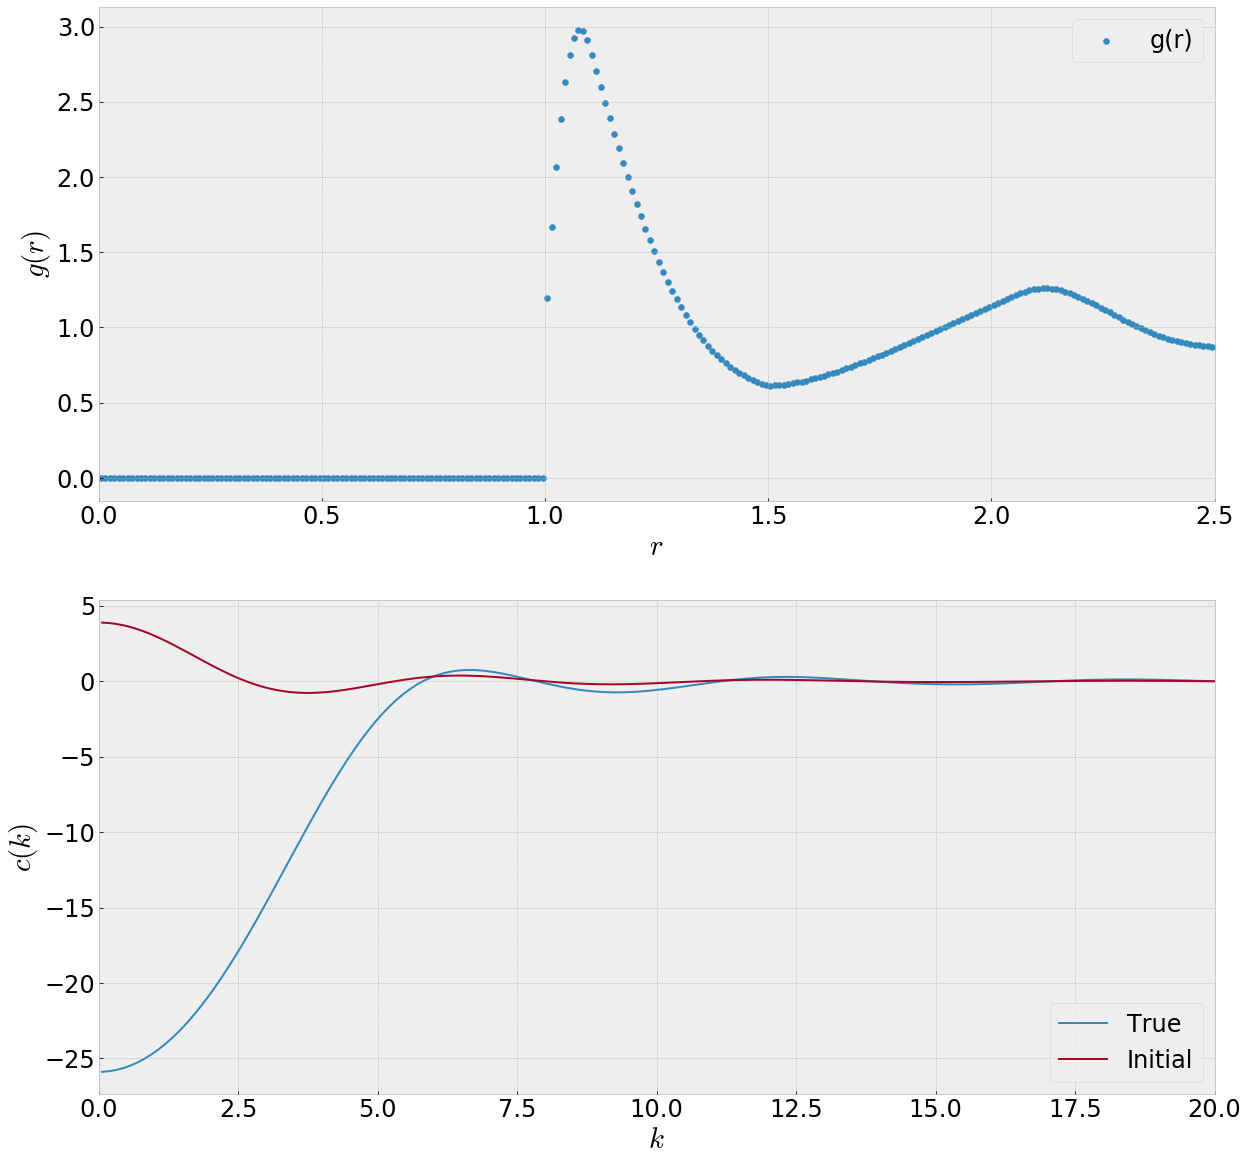

In [391]:
plt.figure(figsize=(20,20))

plt.subplot(2,1,1)
plt.scatter(r_array, g_r, label='g(r)')
plt.ylabel('$g(r)$')
plt.xlabel('$r$')
plt.xlim(0.,2.5)
#plt.ylim(0.95,1.3)
plt.legend()
# plt.grid()

c_k_tmp = initial_c_k(k_array)
plt.subplot(2,1,2)
plt.plot(k_array,c_k, label = 'True')
plt.plot(k_array,c_k_tmp, label = 'Initial')
plt.ylabel('$c(k)$')
plt.xlabel('$k$')
plt.xlim(0,20)
plt.legend()

* final pressure =  2.0458826541407413
* peak of g(r) =  2.9747787115835447
* Dimensionless Compressibility =  20.77599687689892


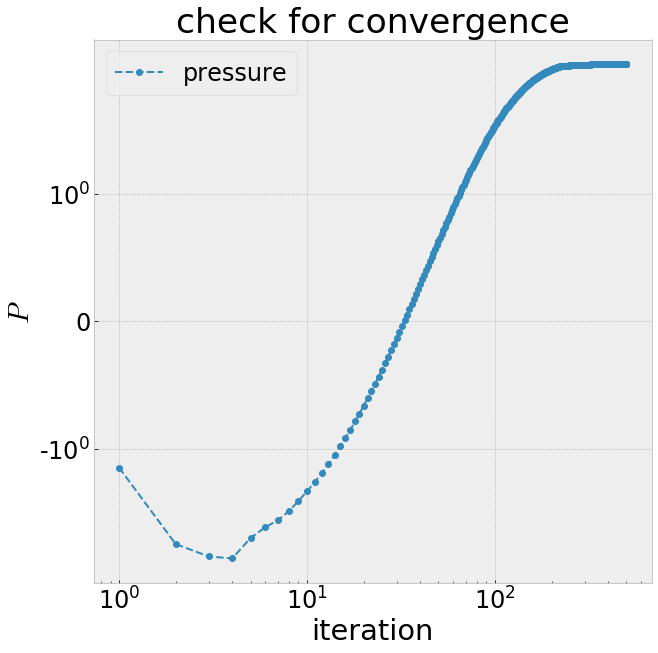

In [392]:
plt.figure(figsize=(10,10))

plt.plot(np.arange(num_iterations)+1, pressure_iter, 'o--', label='pressure')
plt.yscale('symlog')
plt.xscale('log')
plt.ylabel('$P$')
plt.xlabel('iteration')
plt.title("check for convergence")
plt.legend()

print('* final pressure = ',pressure_iter[len(pressure_iter)-1])
print('* peak of g(r) = ',np.max(g_r))
S_k = 1+dimless_dens*c_k/(1-dimless_dens*c_k)
print('* Dimensionless Compressibility = ',1/S_k[0])

## Save Data

In [394]:
#DCF
#c_data = np.array([k_array,c_k]).T
#np.savetxt('c_k.in',c_data)
#PCF
g_data = np.array([r_array,g_r]).T
np.savetxt('g_MHNC_Yukawa_Nohydro_Pe10_kappa2_Gamma150_eta0p4.out',g_data)